  Installing rdkit
  

In [ ]:
!pip install rdkit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 41.4 MB/s eta 0:00:00


Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns


Loading the dataset and cleaning it


In [ ]:
def load_toxicity_dataset():
    df = pd.read_csv("/content/train.csv")   # must contain SMILES and Label

    # Keep only required columns
    df = df[['SMILES', 'Label']]

    # Remove invalid SMILES
    valid_smiles = [Chem.MolFromSmiles(s) is not None for s in df['SMILES']]
    df = df[valid_smiles].reset_index(drop=True)

    print(f"Loaded dataset with {len(df)} molecules")
    print(df['Label'].value_counts())

    return df

df = load_toxicity_dataset()
df.head()


[14:23:10] Explicit valence for atom # 2 Cl, 1, is greater than permitted
[14:23:11] Explicit valence for atom # 0 Cl, 1, is greater than permitted
[14:23:11] WARNING: not removing hydrogen atom without neighbors


Loaded dataset with 7695 molecules
Label
0    6758
1     937
Name: count, dtype: int64


,SMILES,Label
0,CC(C)[C@H](SC(C)=O)C(=O)N[C@H]1CC2=C(C=CC=C2)[...,0
1,O=S1(=O)CC=CC1,0
2,CC(C(O)C1=CC=C(O)C=C1)N2CCC(CC3=CC=CC=C3)CC2,0
3,NC1=CC=C(C=C1)S(=O)(=O)NC2=NC=CS2,0
4,CC(C)(C)CC(C)(C)C1=CC=C(O)C=C1,1


Adding descriptors and Extracting from rdkit

In [ ]:
feature_names = ['MolWt', 'MolLogP', 'NumHAcceptors', 'NumHDonors', 'TPSA']

features = []
for smiles in df['SMILES']:
    mol = Chem.MolFromSmiles(smiles)
    feature_vector = [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.TPSA(mol)
    ]
    features.append(feature_vector)

X = np.array(features)
y = np.array(df['Label'])

print("Feature matrix shape:", X.shape)


[14:23:18] WARNING: not removing hydrogen atom without neighbors


Feature matrix shape: (7695, 5)


Preparing your dataset for training a PyTorch model(Scale (Normalize) Features and Split into train and test set)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


Finding the PyTorch MLP classifier and setting up for training

In [ ]:
class ANNClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = ANNClassifier(X_train.shape[1])


Setting Hyperparmeters

In [ ]:
epochs = 100
batch_size = 42
learning_rate = 0.001

# Boost Hazardous class
pos_weight = torch.tensor([3.0])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)


Creates PyTorch datasets and dataloaders

In [ ]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Training the model

In [ ]:
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item() * X_batch.size(0)

    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")


Epoch [10/100] - Train Loss: 0.6855, Test Loss: 0.6615
Epoch [20/100] - Train Loss: 0.6693, Test Loss: 0.6498
Epoch [30/100] - Train Loss: 0.6629, Test Loss: 0.6444
Epoch [40/100] - Train Loss: 0.6550, Test Loss: 0.6397
Epoch [50/100] - Train Loss: 0.6483, Test Loss: 0.6449
Epoch [60/100] - Train Loss: 0.6455, Test Loss: 0.6394
Epoch [70/100] - Train Loss: 0.6368, Test Loss: 0.6378
Epoch [80/100] - Train Loss: 0.6391, Test Loss: 0.6349
Epoch [90/100] - Train Loss: 0.6369, Test Loss: 0.6350
Epoch [100/100] - Train Loss: 0.6351, Test Loss: 0.6333


Plotting the loss curve

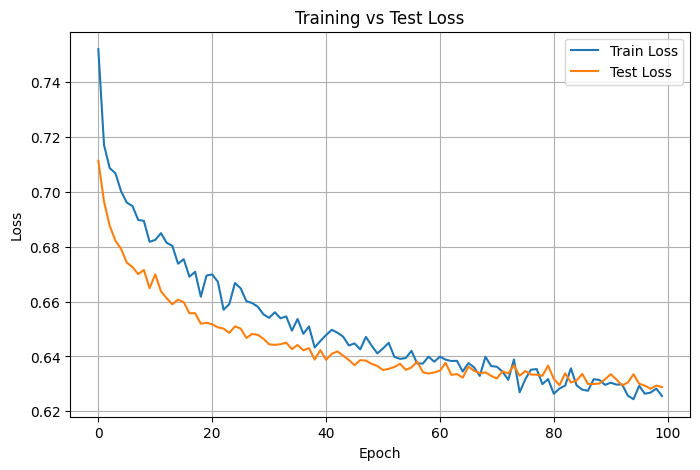

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)
    probs = torch.sigmoid(logits).cpu().numpy()

threshold = 0.35  # tuned for toxicity recall
preds = (probs > threshold).astype(int)

cm = confusion_matrix(y_test, preds)


Ploting the Confusion Matrix

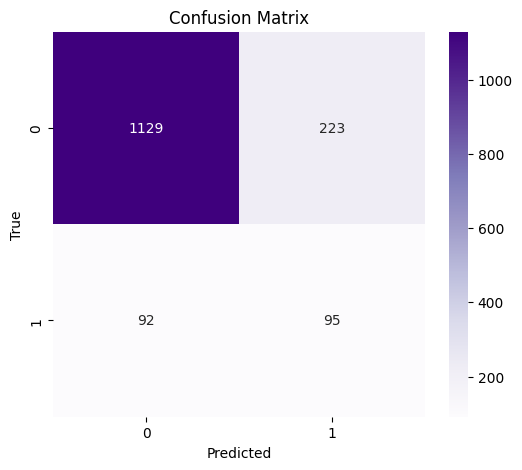

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


 Evaluating the model

In [ ]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, preds, average=None, zero_division=0
)

for i, cls in enumerate([0, 1]):
    print(f"\nClass {cls}")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall:    {recall[i]:.4f}")
    print(f"F1-score:  {f1[i]:.4f}")
    print(f"Support:   {support[i]}")

acc = accuracy_score(y_test, preds)
print(f"\nOverall Accuracy: {acc:.4f}")



Class 0
Precision: 0.9247
Recall:    0.8351
F1-score:  0.8776
Support:   1352

Class 1
Precision: 0.2987
Recall:    0.5080
F1-score:  0.3762
Support:   187

Overall Accuracy: 0.7953


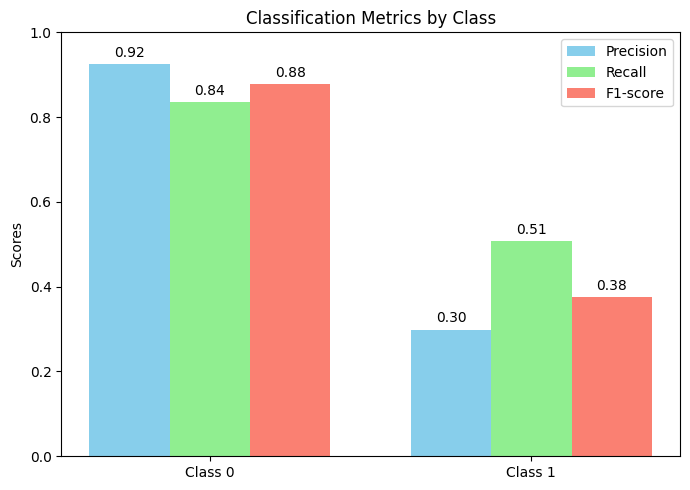

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Classes
classes = ["Class 0", "Class 1"]

# Metrics
precision = [0.9247, 0.2987]
recall    = [0.8351, 0.5080]
f1_score  = [0.8776, 0.3762]

x = np.arange(len(classes))  # label locations
width = 0.25  # width of the bars

# Create plot
fig, ax = plt.subplots(figsize=(7,5))
rects1 = ax.bar(x - width, precision, width, label='Precision', color='skyblue')
rects2 = ax.bar(x, recall, width, label='Recall', color='lightgreen')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score', color='salmon')

# Labels and title
ax.set_ylabel('Scores')
ax.set_ylim(0, 1)
ax.set_title('Classification Metrics by Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

# Display values on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()


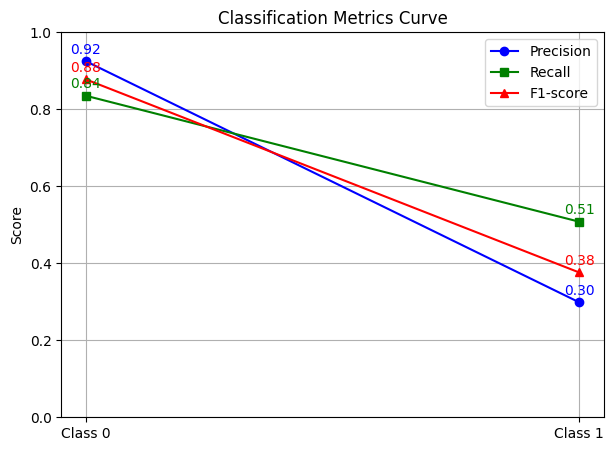

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Classes
classes = ["Class 0", "Class 1"]
x = np.arange(len(classes))

# Metrics
precision = [0.9247, 0.2987]
recall    = [0.8351, 0.5080]
f1_score  = [0.8776, 0.3762]

# Plot curves
plt.figure(figsize=(7,5))
plt.plot(x, precision, marker='o', label='Precision', color='blue')
plt.plot(x, recall, marker='s', label='Recall', color='green')
plt.plot(x, f1_score, marker='^', label='F1-score', color='red')

# Labels and title
plt.xticks(x, classes)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Classification Metrics Curve')
plt.legend()
plt.grid(True)

# Show values on points
for i in range(len(x)):
    plt.text(x[i], precision[i]+0.02, f"{precision[i]:.2f}", ha='center', color='blue')
    plt.text(x[i], recall[i]+0.02, f"{recall[i]:.2f}", ha='center', color='green')
    plt.text(x[i], f1_score[i]+0.02, f"{f1_score[i]:.2f}", ha='center', color='red')

plt.show()
